In [122]:
import numpy as np
import tensorflow as tf
import keras
from matplotlib import pyplot as plt
import altair as alt
import os
import pandas as pd
import faiss

import time

from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, det_curve, ConfusionMatrixDisplay
from sklearn.gaussian_process import GaussianProcessClassifier

from BCBio import GFF
import pprint

In [2]:
'''Define paths to models'''
## Models to test
c_name = "lilac-violet-5132"        # done
r_name = "ancient-morning-5137"     # done
f_name = "wise-plasma-5134"         # done
fc_name = "bumbling-wind-5135"      # done
frac_name = "curious-totem-5139"    # done
rc_name = "glorious-silence-5133"   # done
fr_name = "peachy-hill-5135"        # done
frc_name = "hopeful-violet-5138"    # done
done_names = {'fr':fr_name, 'frc':frc_name, 'rc':rc_name, 'r':r_name, 'f':f_name, 'c':c_name, 'fc':fc_name, 'frac':frac_name}

chkpt_names = {}

model_paths = {}

## Check the model files are stored locally 
for _l,_n in done_names.items():
    n_path = f"models/geneAE_{_n}_fold0.keras"
    if not os.path.exists(n_path):
        print(f"{n_path} not found locally")
    else:
        model_paths[_l] = n_path

## Check if the checkpoint files are stored locally
for _l,_n in chkpt_names.items():
    checkpoints = os.listdir(f"models/checkpoints/{_n}_fold0")
    if len(checkpoints) == 0:
        print(f"{_n} has no local checkpoints")
    else:
        chkpt_files = os.listdir(f"models/checkpoints/{_n}_fold0")
        latest_chkpt = sorted(chkpt_files)[-1]
        model_paths[_l] = f"models/checkpoints/{_n}_fold0/{latest_chkpt}"

In [3]:
def extract_genes(gff_filepath):
    ## Extract gene sequences from a GFF file
    genes = []
    names = []
    with open(gff_filepath) as f:
        for record in GFF.parse(f):
            for feature in record.features:
                seq = str(feature.extract(record.seq))
                if len(seq) <= 5000:
                    genes.append( str(feature.extract(record.seq)) )
                    try:
                        names.append( feature.qualifiers['Name'][0] )
                    except:
                        names.append( "hypothetical_protein" )
    return genes, names
            

In [4]:
'''
Get gene embeddings for each isolate
'''

## Define the annotation directory
gff_dir = "../../gffs/Expanded_dataset_annotations_filtered"


## Load the desired model
gene_ae = tf.keras.models.load_model(model_paths['frac'])


## Loop through each file
embeddings = []
gene_names = []
seq_names = []
lookup_dict = {}

for filename in tqdm(os.listdir(gff_dir)[:50]):
    ## Extract the genes from the annotation file
    genes,names = extract_genes(f"{gff_dir}/{filename}")

    ## Check how many sequences have already been embedded
    embeds = np.zeros((len(genes),2048))
    # print(embeds.shape)
    to_compute_seqs = []
    to_compute_ix = []
    for ix,g in enumerate(genes):
        if g in lookup_dict.keys():
            # print("lookup flag")
            embeds[ix,:] = lookup_dict[g]
        else:
            to_compute_ix.append(ix)
            to_compute_seqs.append(g)

    ## Embed the necessary ones
    if len(to_compute_seqs) > 0:
        gene_tensor = tf.convert_to_tensor(to_compute_seqs)
        compute_embed = gene_ae.encode(gene_tensor, verbose=0)

        # Populate the rest of the embedding tensor
        embeds[to_compute_ix,:] = compute_embed

        ## Store the embedded sequences
        for g,e in zip(to_compute_seqs,compute_embed):
            if g not in lookup_dict.keys():
                lookup_dict[g] = e

    ## Store the desired information
    embeddings.append(embeds)
    gene_names.append(names)
    seq_names.append(filename.rsplit(".",1)[0])
    


2025-12-16 23:04:27.761078: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 63922 MB memory:  -> device: 0, name: AMD Instinct MI250X, pci bus id: 0000:de:00.0
100%|██████████| 50/50 [02:53<00:00,  3.46s/it]


In [5]:
'''
Load metadata
'''
df = pd.read_csv("/scratch/project_465001915/rosstheo/genome_data/expanded-microreact-labels.csv", index_col="id")

In [90]:
'''
Compare the classes?
'''

r_mask = df.loc[seq_names,"Vancomycin Resistance"].to_numpy() == "Yes"
s_mask = df.loc[seq_names,"Vancomycin Resistance"].to_numpy() == "No"

r_points, s_points = [],[]
r_names, s_names = [],[]

for res_flag, sus_flag, points, names in zip(r_mask, s_mask, embeddings, gene_names):
    if res_flag:
        r_points.append(points)
        r_names.append(names)
    elif sus_flag:
        s_points.append(points)
        s_names.append(names)

r_points = np.concatenate(r_points, axis=0)
s_points = np.concatenate(s_points, axis=0)
r_names = np.concatenate(r_names, axis=0)
s_names = np.concatenate(s_names, axis=0)

print("resistant points:", r_points.shape)
print("susceptible points:", s_points.shape)
print(r_names.shape, s_names.shape)



resistant points: (58390, 2048)
susceptible points: (41912, 2048)
(58390,) (41912,)


In [ ]:
'''
Try Random Forest
'''

## Combine all the sequence info
all_points = np.concatenate([r_points, s_points], axis=0)
all_names = np.concatenate([r_names, s_names], axis=0)
all_labels = np.concatenate([np.ones(r_names.shape), np.zeros(s_names.shape)], axis=0)


## Train a random forest classifier
t1 = time.time()
# rf = RandomForestClassifier(max_depth=25).fit(all_points, all_labels)
# rf = LogisticRegression().fit(all_points, all_labels)
rf = GaussianProcessClassifier().fit(all_points,all_labels)
print("training time:", time.time() - t1)

ConfusionMatrixDisplay.from_estimator(rf, all_points, all_labels)

# ## Create index and add resistant points
# d=r_points.shape[1]
# index = faiss.IndexFlatL2(d)   # build the index
# index.add(r_points)
# # index.add(xb)                  # add vectors to the index
# print("number of points:", index.ntotal)

# ## Check nearest neighbors
# k = 50                          # we want to see 4 nearest neighbors
# D, I = index.search(all_points[[4323,  1005]], k) # sanity check
# print(I)
# print(D)

# print(r_names[[4323,  8115, 12417, 17676, 20319]])
# print(r_names[I])

thresholds: (0.4924529579901168, 0.7648263729758611)


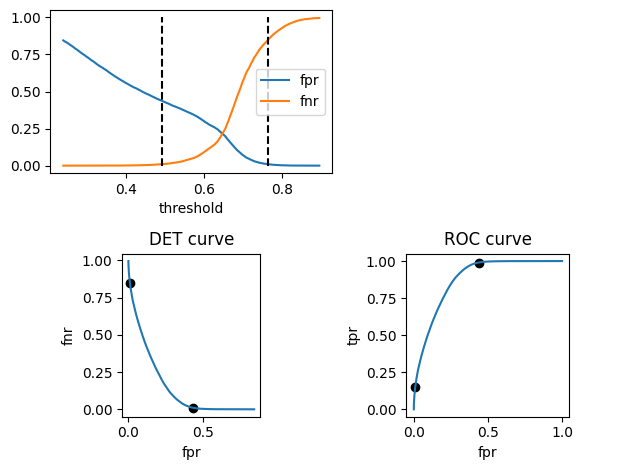

In [110]:
'''
Make fpr and fnr curves
'''
y_probs = rf.predict_proba(all_points)[:,1]
# y_probs = rf_inv.predict_proba(X)[:,1]


f,a = plt.subplots(2,2)

# thresholding
fpr,fnr,thresh = det_curve(all_labels, y_probs)
lo_thresh = np.max(thresh[fnr < 0.01])
hi_thresh = np.min(thresh[fpr < 0.01])

fpr_lo,fnr_lo = fpr[thresh==lo_thresh], fnr[thresh==lo_thresh]
fpr_hi,fnr_hi = fpr[thresh==hi_thresh], fnr[thresh==hi_thresh]
print("thresholds:", (lo_thresh, hi_thresh))

a[0,0].plot(thresh, fpr, label="fpr")
a[0,0].plot(thresh, fnr, label="fnr")
a[0,0].vlines([lo_thresh,hi_thresh], 0,1, "k", linestyles='dashed')
a[0,0].set_xlabel("threshold")
# a[0,0].set_aspect('equal')
a[0,0].legend()
a[0,1].set_axis_off()

# det curve
a[1,0].plot(fpr,fnr)
a[1,0].scatter([fpr_lo,fpr_hi],[fnr_lo,fnr_hi], color='k')
a[1,0].set_xlabel("fpr")
a[1,0].set_ylabel("fnr")
a[1,0].set_aspect('equal')
a[1,0].set_title("DET curve")

# roc curve
fpr,tpr,thresh = roc_curve(all_labels, y_probs)
fpr_lo,tpr_lo = fpr[thresh==lo_thresh], tpr[thresh==lo_thresh]
fpr_hi,tpr_hi = fpr[thresh==hi_thresh], tpr[thresh==hi_thresh]

a[1,1].plot(fpr,tpr)
a[1,1].scatter([fpr_lo,fpr_hi],[tpr_lo,tpr_hi], color='k')
a[1,1].set_xlabel("fpr")
a[1,1].set_ylabel("tpr")
a[1,1].set_aspect('equal')
a[1,1].set_title("ROC curve")

plt.tight_layout()

In [111]:
'''
Detect with probability thresholds
'''

pred_probs = rf.predict_proba(all_points)
lo_probs = pred_probs[:,0] < lo_thresh
hi_probs = pred_probs[:,0] > hi_thresh

lo_genes = all_names[lo_probs]

print(all_names.size)
print(lo_probs.sum())
print(hi_probs.sum())


100302
75198
6308


In [112]:
# np.unique(all_names[lo_probs])
pd.value_counts(all_names[lo_probs])[:50]

/tmp/ipykernel_101562/1534574820.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(all_names[lo_probs])[:50]
/tmp/ipykernel_101562/1534574820.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  pd.value_counts(all_names[lo_probs])[:50]


hypothetical_protein    35446
rpsH                       37
rpsU                       37
rpsL                       37
rpmB                       37
rpsK                       37
rpmJ                       37
rpmE2                      37
infA                       37
rpsZ                       37
rplX                       37
rplN                       37
rpsQ                       37
rplP                       37
rpmC                       36
rpsS                       36
ptsH                       36
atpE_1                     35
rplM                       35
ykuJ                       35
cspD                       35
rplW                       35
secG                       34
czcD                       34
est                        34
metN2                      33
atpG                       33
pstB3_2                    32
ftsE                       32
metP_1                     32
atpF                       32
atpE_2                     32
pspB                       32
tsaE      

In [113]:
pd.value_counts(all_names[hi_probs])[:50]

/tmp/ipykernel_101562/2845209783.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(all_names[hi_probs])[:50]
/tmp/ipykernel_101562/2845209783.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  pd.value_counts(all_names[hi_probs])[:50]


hypothetical_protein    3108
nylA                      10
pbpX_1                     9
pbpX_2                     9
feuB                       9
rpsN2                      9
dctM                       9
aldC                       8
dagK_2                     8
pbp                        8
msrR                       8
dltA                       8
yidC                       8
eriC                       8
rhaR_1                     8
glpQ                       7
glnR                       7
lacM                       7
queG                       7
lrp                        7
rlmH                       7
rpoE                       7
mutY                       7
rpsJ                       7
cggR                       7
pgk                        7
gatB                       7
purL                       7
addB                       7
xpkA                       7
pcp                        7
gadC_1                     7
bceB_1                     7
frlB_1                     7
gmuD_1        